<a href="https://colab.research.google.com/github/sathkumara-smna/258739K/blob/main/ML_LTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Index(['Site_ID', 'Cell_ID', 'Sector_ID', 'trigger_ID', 'Date', 'datetime',
       'BBU_3000', 'BBU_3900', 'LBBP_g1a', 'traffic_load_mbps',
       'Total_Power_W'],
      dtype='object')

MODEL PERFORMANCE
MAE  : 36.41 W
RMSE : 51.38 W
R2   : 0.9947

FEATURE IMPORTANCE
              Feature  Importance
7        sector_count    0.911428
3      g1a_base_power    0.051217
1      bbu_base_power    0.032514
4   g1a_dynamic_power    0.001191
0   traffic_load_mbps    0.001100
6   rru_dynamic_power    0.001087
2   bbu_dynamic_power    0.001057
8            BBU_3900    0.000357
10           LBBP_g1a    0.000050
5      rru_base_power    0.000000
9            BBU_3000    0.000000


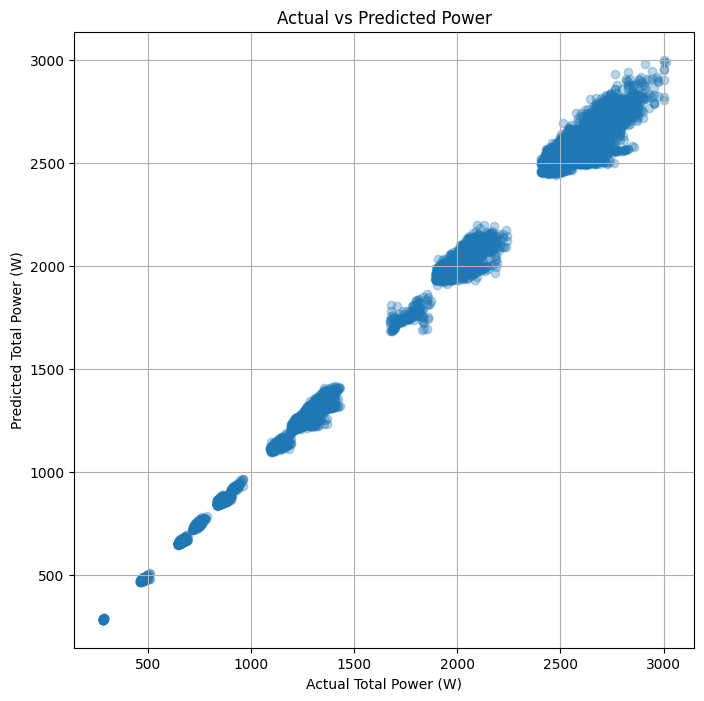


Saved:
LTE_Power_Prediction_Output.xlsx


In [1]:
# =========================================================
# LTE POWER PREDICTION MODEL
# Google Colab Ready Code
# =========================================================

# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

# =========================================================
# 2. LOAD DATA FROM GITHUB
# =========================================================

url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/LTE%20Master%20Raw%20Data%20-%20for%20ML%20-%20Lite.xlsx"

df = pd.read_excel(url)

# =========================================================
# 3. CLEAN COLUMN NAMES
# =========================================================

df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)

print(df.columns)

# =========================================================
# 4. COUNT NUMBER OF SECTORS PER SITE
# =========================================================

sector_count = (
    df.groupby("Site_ID")["Sector_ID"]
    .nunique()
)

df["sector_count"] = df["Site_ID"].map(sector_count)

# =========================================================
# 5. DEFINE BASE POWER VALUES
# =========================================================

BBU3900_POWER = 55
BBU3000_POWER = 65

LBBP_G1A_BASE = 26.67

RRU_BASE_POWER = 180

# =========================================================
# 6. CALCULATE BBU BASE POWER PER SECTOR
# =========================================================

df["bbu_base_power"] = (
    (
        (df["BBU_3900"] * BBU3900_POWER) +
        (df["BBU_3000"] * BBU3000_POWER)
    )
    / df["sector_count"]
)

# =========================================================
# 7. CALCULATE G1A BASE POWER PER SECTOR
# =========================================================

df["g1a_base_power"] = (
    (df["LBBP_g1a"] * LBBP_G1A_BASE)
    / df["sector_count"]
)

# =========================================================
# 8. RRU BASE POWER
# =========================================================

df["rru_base_power"] = RRU_BASE_POWER

# =========================================================
# 9. BBU DYNAMIC POWER
# =========================================================
# Based on traffic increments

def calc_bbu_dynamic(traffic):

    if traffic <= 15:
        return (traffic / 15) * 3

    elif traffic <= 30:
        return (traffic / 30) * 6

    elif traffic <= 45:
        return (traffic / 45) * 9

    elif traffic <= 60:
        return (traffic / 60) * 12

    elif traffic <= 75:
        return (traffic / 75) * 15

    else:
        return min((traffic / 90) * 18, 18)

df["bbu_dynamic_power"] = (
    df["traffic_load_mbps"]
    .apply(calc_bbu_dynamic)
)

# =========================================================
# 10. G1A DYNAMIC POWER
# =========================================================

df["g1a_dynamic_power"] = (
    (
        df["traffic_load_mbps"] / 100
    )
    * 12
)

# =========================================================
# 11. RRU DYNAMIC POWER
# =========================================================

df["rru_dynamic_power"] = (
    (
        df["traffic_load_mbps"] / 100
    )
    * 60
)

# =========================================================
# 12. ESTIMATED SECTOR POWER
# =========================================================

df["estimated_sector_power"] = (

    df["bbu_base_power"] +

    df["g1a_base_power"] +

    df["rru_base_power"] +

    df["bbu_dynamic_power"] +

    df["g1a_dynamic_power"] +

    df["rru_dynamic_power"]

)

# =========================================================
# 13. MACHINE LEARNING FEATURES
# =========================================================

features = [

    "traffic_load_mbps",

    "bbu_base_power",
    "bbu_dynamic_power",

    "g1a_base_power",
    "g1a_dynamic_power",

    "rru_base_power",
    "rru_dynamic_power",

    "sector_count",

    "BBU_3900",
    "BBU_3000",
    "LBBP_g1a"

]

X = df[features]

y = df["Total_Power_W"]

# =========================================================
# 14. TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,
    random_state=42

)

# =========================================================
# 15. TRAIN MODEL
# =========================================================

model = RandomForestRegressor(

    n_estimators=200,

    max_depth=12,

    random_state=42,

    n_jobs=-1

)

model.fit(X_train, y_train)

# =========================================================
# 16. PREDICTIONS
# =========================================================

y_pred = model.predict(X_test)

# =========================================================
# 17. EVALUATION
# =========================================================

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print(f"MAE  : {mae:.2f} W")
print(f"RMSE : {rmse:.2f} W")
print(f"R2   : {r2:.4f}")

# =========================================================
# 18. FEATURE IMPORTANCE
# =========================================================

importance = pd.DataFrame({

    "Feature": features,
    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n==============================")
print("FEATURE IMPORTANCE")
print("==============================")

print(importance)

# =========================================================
# 19. PLOT ACTUAL vs PREDICTED
# =========================================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual Total Power (W)")
plt.ylabel("Predicted Total Power (W)")

plt.title("Actual vs Predicted Power")

plt.grid(True)

plt.show()

# =========================================================
# 20. SAVE RESULTS
# =========================================================

df["Predicted_Total_Power"] = model.predict(X)

df.to_excel(
    "LTE_Power_Prediction_Output.xlsx",
    index=False
)

print("\nSaved:")
print("LTE_Power_Prediction_Output.xlsx")